In [1]:
# ============================================================
# Task 1: Term Deposit Subscription Prediction
# ============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, accuracy_score,
                             confusion_matrix, roc_curve, auc, f1_score)
import shap
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. LOAD & EXPLORE DATASET
# ============================================================
data = pd.read_csv(r"D:\User(D)\Download\bank (1).csv")

# Your file uses 'deposit' as target — rename to 'y'
data.rename(columns={'deposit': 'y'}, inplace=True)

print("Shape:", data.shape)
print("\nColumns:", data.columns.tolist())
print("\nFirst 5 rows:")
print(data.head())
print("\nData Types:\n", data.dtypes)
print("\nMissing Values:\n", data.isnull().sum())
print("\nTarget Distribution:\n", data['y'].value_counts())
print(f"\nSubscription Rate: {(data['y']=='yes').mean()*100:.2f}%")
print(data.head())


Shape: (11162, 17)

Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

First 5 rows:
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome    y  
0    5   may      1042         1     -1         0  unknown  yes  
1    5   may      1467         1     -1         0  unknown  yes  
2    5   may      1389         1     -1         0  unknown  yes  
3    5   may       579         1    

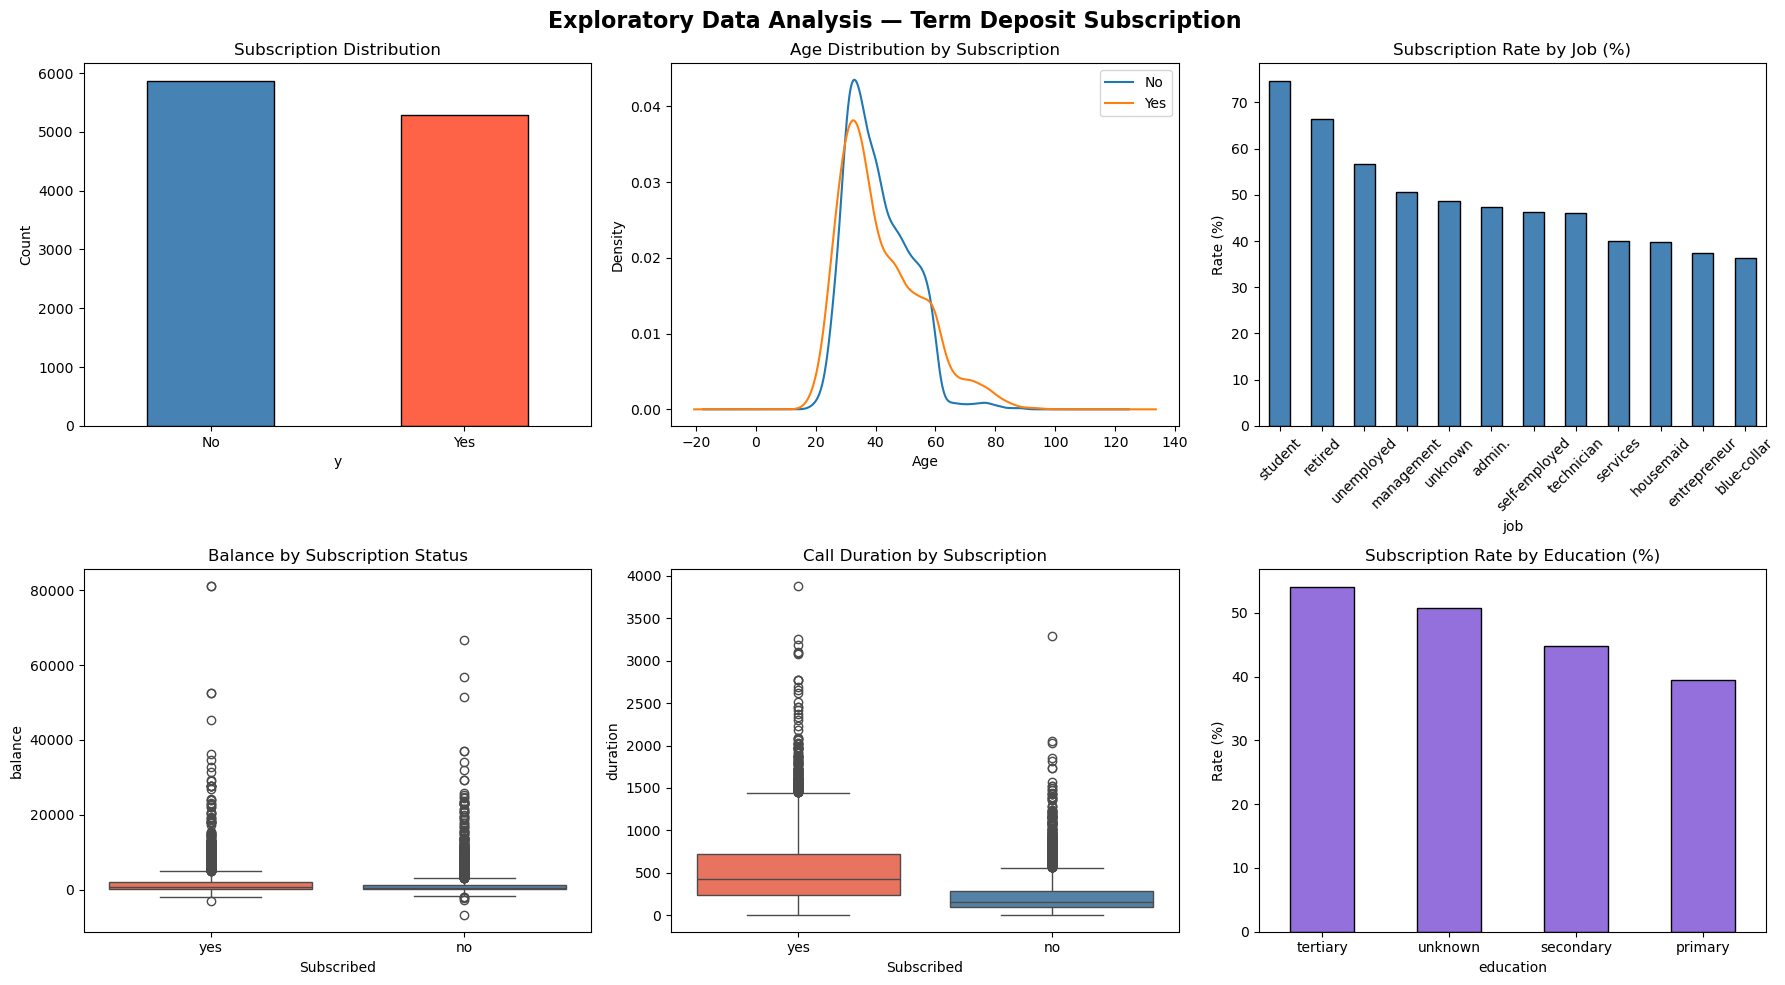

In [2]:
# ============================================================
# 2. EXPLORATORY DATA ANALYSIS
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Exploratory Data Analysis — Term Deposit Subscription',
             fontsize=16, fontweight='bold')

# Plot 1: Target Distribution
data['y'].value_counts().plot(kind='bar', ax=axes[0,0],
                               color=['steelblue','tomato'], edgecolor='black')
axes[0,0].set_title('Subscription Distribution')
axes[0,0].set_xticklabels(['No','Yes'], rotation=0)
axes[0,0].set_ylabel('Count')

# Plot 2: Age Distribution by Outcome
for label, grp in data.groupby('y')['age']:
    grp.plot(kind='kde', ax=axes[0,1], label=label)
axes[0,1].set_title('Age Distribution by Subscription')
axes[0,1].set_xlabel('Age')
axes[0,1].legend(['No','Yes'])

# Plot 3: Job vs Subscription Rate
job_sub = data.groupby('job')['y'].apply(
    lambda x: (x=='yes').mean()*100).sort_values(ascending=False)
job_sub.plot(kind='bar', ax=axes[0,2], color='steelblue', edgecolor='black')
axes[0,2].set_title('Subscription Rate by Job (%)')
axes[0,2].tick_params(axis='x', rotation=45)
axes[0,2].set_ylabel('Rate (%)')

# Plot 4: Balance vs Subscription
sns.boxplot(data=data, x='y', y='balance',
            palette={'no':'steelblue','yes':'tomato'}, ax=axes[1,0])
axes[1,0].set_title('Balance by Subscription Status')
axes[1,0].set_xlabel('Subscribed')

# Plot 5: Duration vs Subscription
sns.boxplot(data=data, x='y', y='duration',
            palette={'no':'steelblue','yes':'tomato'}, ax=axes[1,1])
axes[1,1].set_title('Call Duration by Subscription')
axes[1,1].set_xlabel('Subscribed')

# Plot 6: Education vs Subscription
edu_sub = data.groupby('education')['y'].apply(
    lambda x: (x=='yes').mean()*100).sort_values(ascending=False)
edu_sub.plot(kind='bar', ax=axes[1,2], color='mediumpurple', edgecolor='black')
axes[1,2].set_title('Subscription Rate by Education (%)')
axes[1,2].tick_params(axis='x', rotation=0)
axes[1,2].set_ylabel('Rate (%)')

plt.tight_layout()
plt.show()



In [3]:
# ============================================================
# 3. ENCODE CATEGORICAL FEATURES
# ============================================================
data_encoded = data.copy()

# Label encode binary target
le = LabelEncoder()
data_encoded['y'] = le.fit_transform(data_encoded['y'])  # no=0, yes=1

# Label encode other binary columns
for col in ['default', 'housing', 'loan']:
    if col in data_encoded.columns:
        data_encoded[col] = le.fit_transform(data_encoded[col])

# One-Hot encode multi-class columns
ohe_cols = [c for c in ['job','marital','education','contact','month','poutcome']
            if c in data_encoded.columns]
data_encoded = pd.get_dummies(data_encoded, columns=ohe_cols, drop_first=True)

# Fix boolean dtype (pandas 2.x)
bool_cols = data_encoded.select_dtypes(include='bool').columns
data_encoded[bool_cols] = data_encoded[bool_cols].astype(int)

print("\nShape after encoding:", data_encoded.shape)
print("Sample:\n", data_encoded.head(2))




Shape after encoding: (11162, 43)
Sample:
    age  default  balance  housing  loan  day  duration  campaign  pdays  \
0   59        0     2343        1     0    5      1042         1     -1   
1   56        0       45        0     0    5      1467         1     -1   

   previous  ...  month_jul  month_jun  month_mar  month_may  month_nov  \
0         0  ...          0          0          0          1          0   
1         0  ...          0          0          0          1          0   

   month_oct  month_sep  poutcome_other  poutcome_success  poutcome_unknown  
0          0          0               0                 0                 1  
1          0          0               0                 0                 1  

[2 rows x 43 columns]


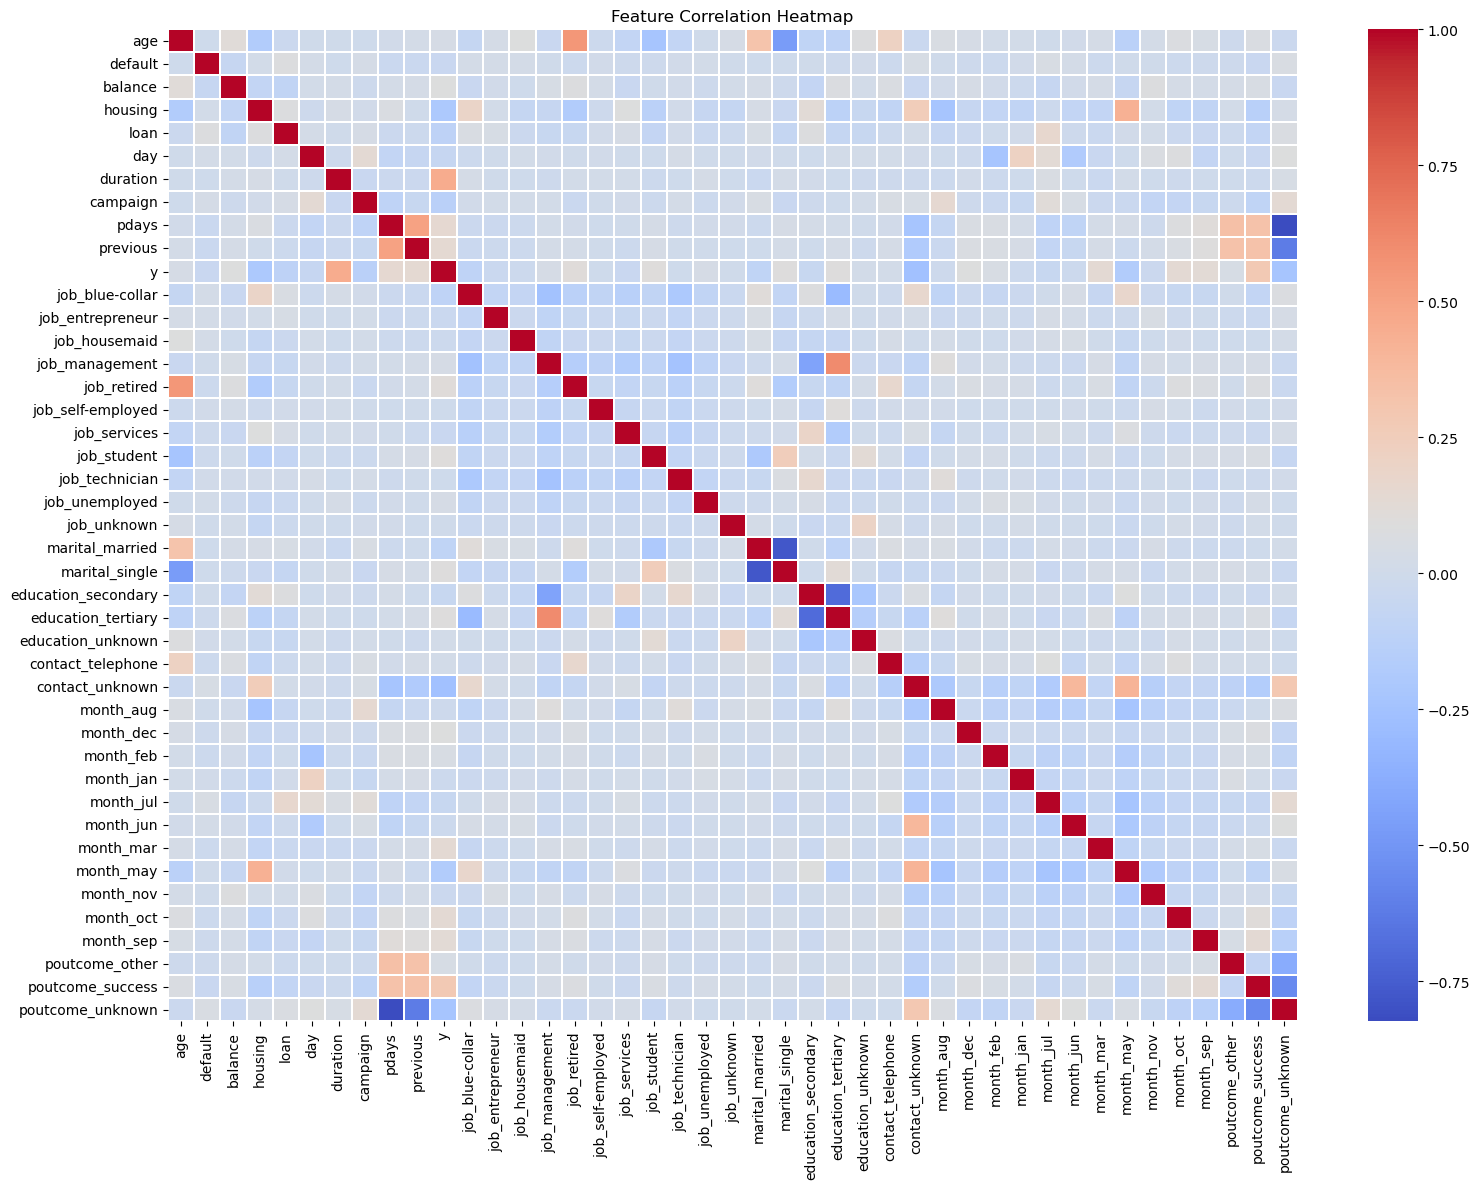

In [4]:
# ============================================================
# 4. CORRELATION HEATMAP
# ============================================================
plt.figure(figsize=(16, 12))
sns.heatmap(data_encoded.corr(), annot=False, cmap='coolwarm', linewidths=0.3)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()



In [5]:
# ============================================================
# 5. SPLIT FEATURES AND TARGET
# ============================================================
X = data_encoded.drop('y', axis=1)
y = data_encoded['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Subscription rate in test set: {y_test.mean()*100:.2f}%")




Training: 8929 | Test: 2233
Subscription rate in test set: 47.38%


In [6]:
# ============================================================
# 6A. LOGISTIC REGRESSION
# ============================================================
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train, y_train)
lr_pred  = lr_model.predict(X_test)

print("\n========== LOGISTIC REGRESSION ==========")
print(f"Accuracy : {accuracy_score(y_test, lr_pred)*100:.2f}%")
print(f"F1-Score : {f1_score(y_test, lr_pred):.4f}")
print(classification_report(y_test, lr_pred, target_names=['No','Yes']))

# ============================================================
# 6B. RANDOM FOREST
# ============================================================
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                   random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred  = rf_model.predict(X_test)

print("\n========== RANDOM FOREST ==========")
print(f"Accuracy : {accuracy_score(y_test, rf_pred)*100:.2f}%")
print(f"F1-Score : {f1_score(y_test, rf_pred):.4f}")
print(classification_report(y_test, rf_pred, target_names=['No','Yes']))




========== LOGISTIC REGRESSION ==========
Accuracy : 82.58%
F1-Score : 0.8166
              precision    recall  f1-score   support

          No       0.84      0.83      0.83      1175
         Yes       0.81      0.82      0.82      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233


========== RANDOM FOREST ==========
Accuracy : 86.34%
F1-Score : 0.8614
              precision    recall  f1-score   support

          No       0.90      0.83      0.87      1175
         Yes       0.83      0.90      0.86      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.87      0.86      2233
weighted avg       0.87      0.86      0.86      2233



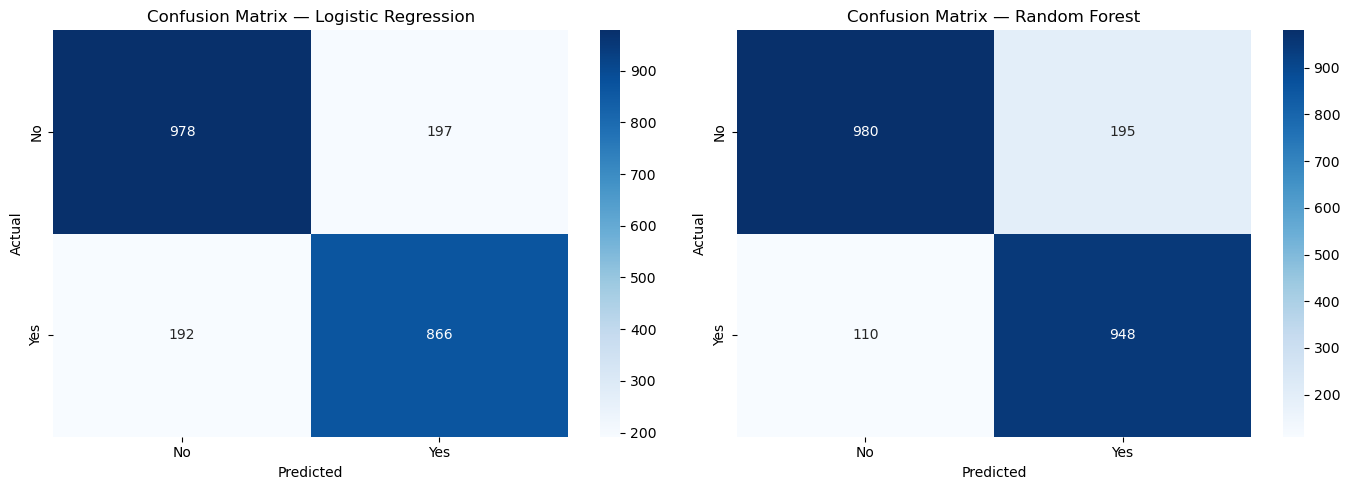

In [7]:
# ============================================================
# 7. CONFUSION MATRICES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, preds, title in zip(axes,
                             [lr_pred, rf_pred],
                             ['Logistic Regression','Random Forest']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No','Yes'],
                yticklabels=['No','Yes'])
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()



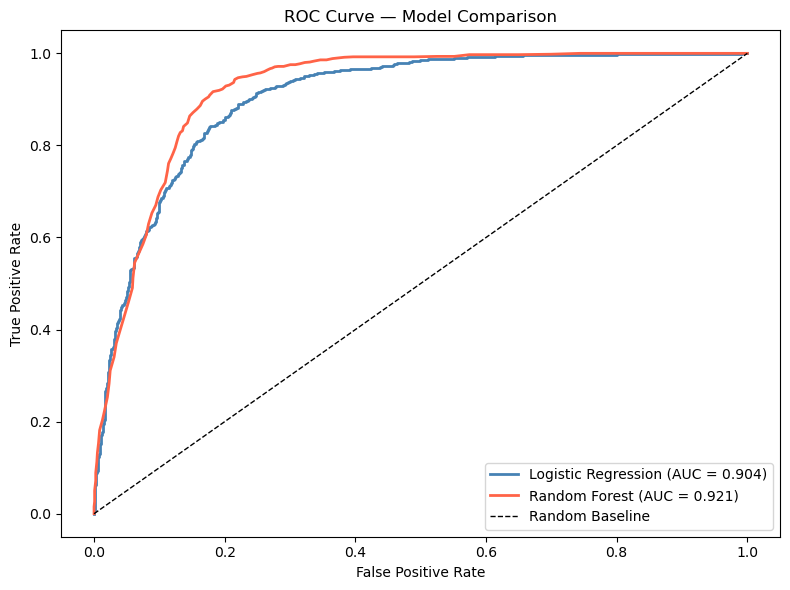

In [8]:
# ============================================================
# 8. ROC CURVE — BOTH MODELS
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))
for model, name, color in [
    (lr_model, 'Logistic Regression', 'steelblue'),
    (rf_model, 'Random Forest',       'tomato')
]:
    probs       = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0,1],[0,1],'k--', lw=1, label='Random Baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Model Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()



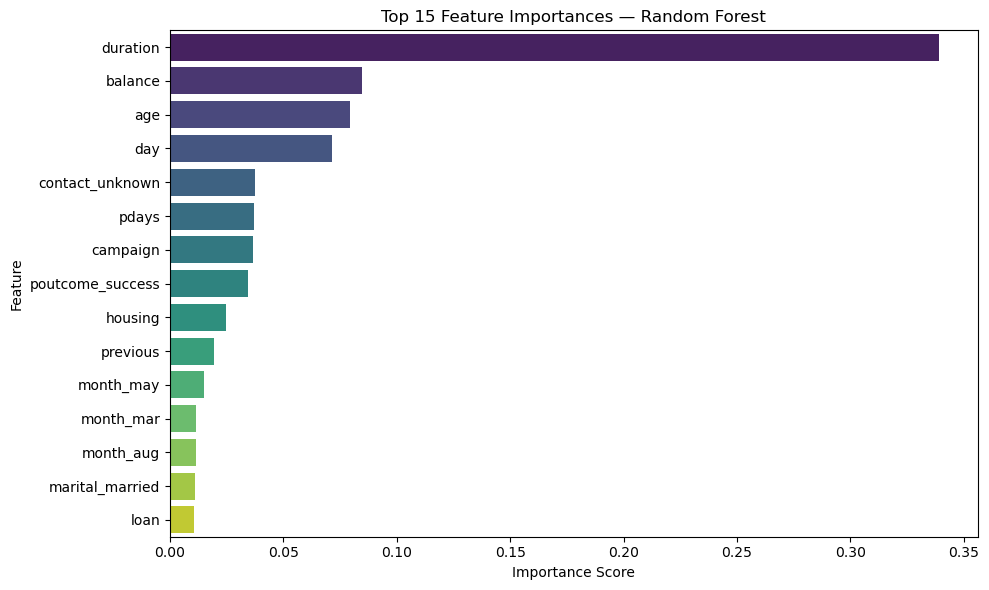


Top 10 Features:
         Feature  Importance
        duration    0.339176
         balance    0.084792
             age    0.079415
             day    0.071633
 contact_unknown    0.037639
           pdays    0.036889
        campaign    0.036427
poutcome_success    0.034333
         housing    0.024823
        previous    0.019492


In [9]:
# ============================================================
# 9. FEATURE IMPORTANCE — RANDOM FOREST
# ============================================================
feat_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(feat_imp.head(10).to_string(index=False))



In [ ]:
# ============================================================
# 10. SHAP — 
# Explain 5 individual predictions using Random Forest
# ============================================================
print("\n========== SHAP EXPLAINABILITY ==========")

# Build SHAP explainer on training data
explainer    = shap.TreeExplainer(rf_model)
X_test_reset = X_test.reset_index(drop=True)

# --- 10A. SHAP Summary Plot (global feature importance) ---
print("Generating SHAP Summary Plot...")
shap_values = explainer.shap_values(X_test_reset)

# shap_values[1] = values for class 1 (subscribed = yes)
shap.summary_plot(shap_values[1], X_test_reset, plot_type='bar',
                  max_display=15, show=False)
plt.title('SHAP Feature Importance (Global)')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values[1], X_test_reset,
                  max_display=15, show=False)
plt.title('SHAP Summary — Feature Impact Direction')
plt.tight_layout()
plt.show()

# --- 10B. SHAP Force Plots — 5 Individual Predictions ---
print("\nExplaining 5 individual predictions...\n")

# Pick 5 samples: mix of correct/incorrect predictions
sample_indices = [0, 1, 2, 3, 4]

for i, idx in enumerate(sample_indices):
    actual    = "Subscribed " if y_test.iloc[idx] == 1 else "Not Subscribed "
    predicted = "Subscribed " if rf_pred[idx]      == 1 else "Not Subscribed "
    correct   = " CORRECT" if y_test.iloc[idx] == rf_pred[idx] else " WRONG"

    print(f"--- Customer {i+1} (Test Index {idx}) ---")
    print(f"  Actual    : {actual}")
    print(f"  Predicted : {predicted}  {correct}")

    # Waterfall plot for each customer
    shap_exp = shap.Explanation(
        values        = shap_values[1][idx],
        base_values   = explainer.expected_value[1],
        data          = X_test_reset.iloc[idx],
        feature_names = X_test_reset.columns.tolist()
    )
    shap.plots.waterfall(shap_exp, max_display=10, show=False)
    plt.title(f'SHAP Waterfall — Customer {i+1} | {actual} | Pred: {predicted}')
    plt.tight_layout()
    plt.show()
  
print(plt.show())


In [ ]:
# ============================================================
# 11. BUSINESS INSIGHTS
# ============================================================
print("\n========== BUSINESS INSIGHTS ==========")

print("\n Top 5 Jobs with Highest Subscription Rate:")
print(job_sub.head())

print("\n Subscription Rate by Education:")
print(edu_sub.sort_values(ascending=False))

print("\n Average Call Duration:")
print(data.groupby('y')['duration'].mean().rename({'no':'Not Subscribed','yes':'Subscribed'}))

print("\n Average Balance:")
print(data.groupby('y')['balance'].mean().rename({'no':'Not Subscribed','yes':'Subscribed'}))

print("\n Model Comparison Summary:")
print(f"  Logistic Regression  →  Accuracy: {accuracy_score(y_test,lr_pred)*100:.2f}%  |  F1: {f1_score(y_test,lr_pred):.4f}")
print(f"  Random Forest        →  Accuracy: {accuracy_score(y_test,rf_pred)*100:.2f}%  |  F1: {f1_score(y_test,rf_pred):.4f}")

In [ ]:
!pip install shap